
# 🏞️ Random Forest Regressor vs ExtraTrees

Aquest notebook mostra un exemple d'us del Model **Random Forest Regressor**. Una de les estratègies d'*Ensemble Models*. Concretament Random Forest utilitza l'estratègia de **Bagging** o **Bootstrap Aggregating**

---

## 🎯 Objectius
- Veure un exemple d'ús d'un Random Forest Regressor
- Veure la diferència entre un Decision Tree


##  🏠 Boston Housing

Volem predir la variable MEDV. valor mijtà de les vivendes.

En el conjunt de dades tenim:
- **CRIM**: taxa de delinqüència per càpita per ciutat.
- **ZN**: proporció de sòl residencial dividit per a segments de més de 25.000 peus quadrats.
- **INDUS**: proporció de superfície comercial no minorista per ciutat.
- **CHAS**: variable binària sobre el riu Charles (= 1 si la zona limita amb el riu; 0 en cas contrari).
- **NOX**: concentració d'òxids nítrics (parts de 10 milions).
- **RM**: nombre mitjà d'habitacions per habitatge.
- **EDAT**: proporció d'habitatges ocupats construïts abans del 1940.
- **DIS**: distància ponderada a cinc centres de treball a la ciutat de Boston.
- **RAD**: índex daccessibilitat a les autopistes radials.
- **TAX**: impost sobre béns immobles de valor íntegre per cada 10.000 dólars
- **PTRATIO**: ràtio alumnes-professor per ciutat.
- **LSTAT**: % de la població considerat de classe baixa.
- **MEDV** (variable a predir): valor mitjà dels habitatges en milers de $.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score



# Load the Boston Housing dataset
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']
df.head()



/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
df.shape

(506, 14)


## 🧠 Dividim el conjunt de dades,  creem el model i avaluem


In [ ]:
# Dividim el conjunt de dades train/test
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 123
                                    )

print(f"Train: {X_train.shape[0]} observacions")
print(f"Test: {X_test.shape[0]} observacions")


# Creem el model
# n_estimators = 10,              # Número d'arbres que s'utilitzarà en el model
# criterion    = 'squared_error', #
# max_depth    = None,            # Produnditat màxima dels arbres
# max_features = 1,               # Número de predictors a cada divisio de l'arbre
# oob_score    = False,           # Si es calcula o no el out-of-bag r2.
# n_jobs       = -1,              # Número de cores utilitzats (-1=tots)
model_rfr = RandomForestRegressor(random_state = 54)

model_rfr.fit(X_train, y_train)

# Avaluem el model
# ==============================================================================
y_pred = model_rfr.predict(X=X_test)

rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
print(f"El error (rmse) de test es: {rmse}")

r2= r2_score(y_true=y_test, y_pred=y_pred)
print(f"El error (r2) de test es: {r2}")

Train: 379 observacions
Test: 127 observacions
El error (rmse) de test es: 4.048799167751768
El error (r2) de test es: 0.7923446931118573


## 🧮 Ajust del hiperparàmetres

Per defecte el paràmetre `n_estimator=10` volem veure quin efecte té l'ús d'aquest hiperparàmetre en el resultat final.

Per això crearem 30 models donant a n_estimator el valors de [1,5,10,15,..150]

Valor óptimo de n_estimators: 130


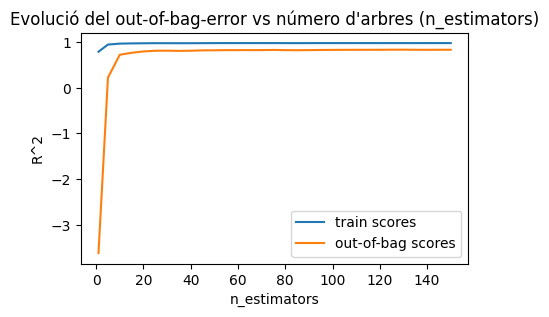

In [ ]:
# Validació utilitzant el Out-of-Bag error
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

train_scores = []
oob_scores   = []
#r2_scores    = []

# Valors avaluats
estimator_range = [1] + list(range(5, 155, 5))

# Bucle per entrenar un model amb cada valor de n_estmators i extreure l'error d'entrenament.
for n_estimators in estimator_range:
    modelo = RandomForestRegressor(
                n_estimators = n_estimators,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = 1,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 54
             )
    modelo.fit(X_train, y_train)
    train_scores.append(modelo.score(X_train, y_train))
    oob_scores.append(modelo.oob_score_)

    #y_pred = modelo.predict(X=X_test)
    #r2_scores.append(r2_score(y_true=y_test, y_pred=y_pred))

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(estimator_range, train_scores, label="train scores")
ax.plot(estimator_range, oob_scores, label="out-of-bag scores")
#ax.plot(estimator_range, r2_scores, label="r2 scores")
ax.set_ylabel("R^2")
ax.set_xlabel("n_estimators")
ax.set_title("Evolució del out-of-bag-error vs número d'arbres (n_estimators)")
plt.legend();
print(f"Valor óptimo de n_estimators: {estimator_range[np.argmax(oob_scores)]}")

En el gràfic anterior veiem que el valor òptim de `n_estimators` és aquell que:
- L'**OOB score** (validació interna) s’estabilitza, és a dir, deixa de millorar significativament.
- La **diferència** entre **train_score** i **oob_score** és petita i constant.
- Afegir més arbres **no millora el rendiment**, només augmenta el cost computacional.

Mirem com `oob_score` s'estabilitza i veiem que la millora és inferior a un llindar prefixat i petit (0.001)

In [ ]:
# Convertim a array per treballar més fàcilment
import numpy as np
oob_scores = np.array(oob_scores)

# Diferència entre passos consecutius
diff = np.diff(oob_scores)

# Quan la millora és inferior a un llindar petit
threshold = 0.001  # (0.1% de millora)
optimal_idx = np.where(diff < threshold)[0][0] + 1
optimal_estimators = estimator_range[optimal_idx]
print(f"n_estimators òptim ≈ {optimal_estimators}")


n_estimators òptim ≈ 35


Mirem com `oob_score` s'estabilitza i veiem que la millora és inferior a un llindar prefixat i petit (0.001)

In [ ]:
import numpy as np

# Convertim a array per a càlculs vectorials
train_scores = np.array(train_scores)
oob_scores   = np.array(oob_scores)

# Diferència entre passos consecutius de l'OOB score
oob_diff = np.diff(oob_scores)

# Diferència entre train i oob per a cada n_estimators
gap = train_scores - oob_scores
gap_diff = np.diff(gap)

# Llindars de tolerància
threshold_oob = 0.001   # millora mínima acceptable de l'OOB
threshold_gap = 0.002   # variació mínima acceptable del gap

# Criteri: el punt on l'OOB s'estabilitza i el gap deixa de variar
for i in range(1, len(estimator_range)-1):
    if abs(oob_diff[i-1]) < threshold_oob and abs(gap_diff[i-1]) < threshold_gap:
        optimal_estimators = estimator_range[i]
        break

print(f"n_estimators òptim ≈ {optimal_estimators}")


n_estimators òptim ≈ 60


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor


## ExtraTreeRegressor

Utilitzem per el mateix conjunt de dades de Boston utilitzan un Extra Regressor i el compararem amb un RandomForestRegressor. utilitzarem el mateix número d'arbres.
A la compariva mirarem el temps d'entrenament en cadascun d'ells.


=== Random Forest ===
R²:    0.7998
RMSE:  3.97

=== Extra Trees ===
R²:    0.8222
RMSE:  3.75

Temps d'entrenament:
Random Forest: 0.145 s
Extra Trees:   0.088 s


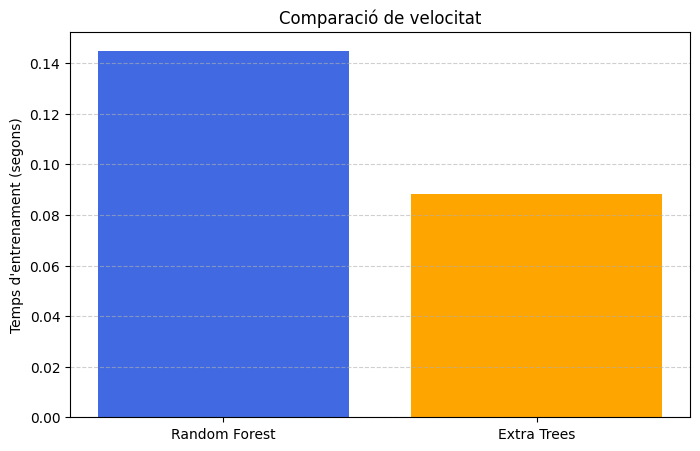

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score


# Load the Boston Housing dataset
# --------------------------
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']

# Dividim el conjunt de dades train/test
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns="MEDV"),
                                        df['MEDV'],
                                        test_size = 0.25,
                                        random_state = 123
                                    )

# Definim els dos models
# --------------------------
rf = RandomForestRegressor(
    n_estimators=60,
    bootstrap=True, # Valor per defecte
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

et = ExtraTreesRegressor(
    n_estimators=60,
    bootstrap=False, # Valor per defecte
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Entrenem i mesurem el temps i rendiment
# ---------------------------------------

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
et.fit(X_train, y_train)
et_time = time.time() - start


# Avaluem els models
# ------------------

models = {'Random Forest': rf, 'Extra Trees': et}

for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  {rmse:.2f}")

print("\nTemps d'entrenament:")
print(f"Random Forest: {rf_time:.3f} s")
print(f"Extra Trees:   {et_time:.3f} s")

# Gràfic comparatiu
# ---------------------
plt.figure(figsize=(8, 5))
plt.bar(['Random Forest', 'Extra Trees'], [rf_time, et_time], color=['royalblue', 'orange'])
plt.ylabel("Temps d'entrenament (segons)")
plt.title("Comparació de velocitat")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Exemple anterior, però utilitzant una validació creuada per comparar els resultats

Explicació dels passos
| Pas     | Què fa                                                                                                 |
| ------- | ------------------------------------------------------------------------------------------------------ |
| **1️⃣** | Obtenim el conjunt de dades de regressió. (hi ha comentat un exmpel de com generar dades sintètiques)                                          |
| **2️⃣** | Definim els dos models amb els mateixos hiperparàmetres principals (`n_estimators`, `random_state`).   |
| **3️⃣** | Preparem una estratègia de validació creuada de 5 particions amb `KFold`.                              |
| **4️⃣** | Fem validació creuada amb `cross_val_score`, que entrena i avalua el model 5 cops amb dades diferents. |
| **5️⃣** | Mostrem els valors de R² per cada fold i la seva mitjana i desviació estàndard.                        |
| **6️⃣** | Dibuixem un gràfic boxplot per comparar visualment el rendiment dels dos models.                       |


=== Random Forest ===
Scores per fold: [0.875 0.866 0.812 0.913 0.887]
Mitjana R²: 0.8706 ± 0.0332

=== Extra Trees ===
Scores per fold: [0.873 0.88  0.853 0.93  0.876]
Mitjana R²: 0.8822 ± 0.0256


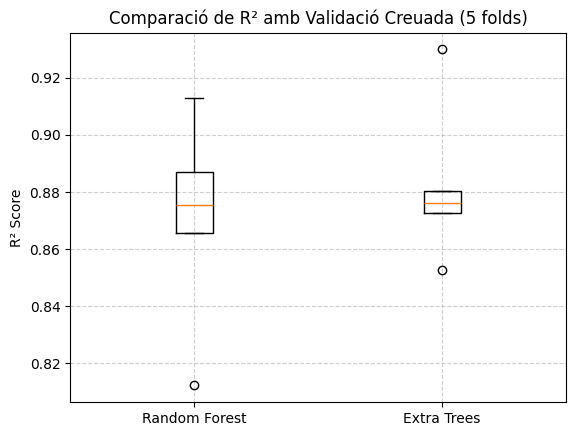

In [ ]:
# ================================================================
# Comparació amb VALIDACIÓ CREUADA de RandomForest vs ExtraTrees
# ================================================================

import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# 1 Load Boston Dataset
# ----------------------------------------------------------------
boston = fetch_openml(name='boston')

df = boston['data']
df['MEDV'] = boston['target']
X = df.drop(columns="MEDV")
y = df['MEDV']

# Generem dades sintètiques
# ----------------------------------------------------------------
#X, y = make_regression(
#    n_samples=1500,
#    n_features=12,
#    noise=25,
#    random_state=42
#)


# 2 Definim els models
# ----------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 3 Definim l'estratègia de validació creuada
# ----------------------------------------------------------------
# 5 particions (5 folds)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 4 Avaluem amb cross-validation (mètrica = R²)
# ----------------------------------------------------------------
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2', n_jobs=-1)
et_scores = cross_val_score(et, X, y, cv=cv, scoring='r2', n_jobs=-1)

# 5 Mostrem resultats
# ----------------------------------------------------------------
print("=== Random Forest ===")
print(f"Scores per fold: {np.round(rf_scores, 3)}")
print(f"Mitjana R²: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

print("\n=== Extra Trees ===")
print(f"Scores per fold: {np.round(et_scores, 3)}")
print(f"Mitjana R²: {et_scores.mean():.4f} ± {et_scores.std():.4f}")

# 6 Comparació visual (opcional)
# ----------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.boxplot([rf_scores, et_scores], labels=["Random Forest", "Extra Trees"])
plt.title("Comparació de R² amb Validació Creuada (5 folds)")
plt.ylabel("R² Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
